In [2]:
# CUSTOMER CHURN PREDICTION USING MACHINE LEARNING
# For Data Manipulation
import pandas as pd
import numpy as np
# it is for Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')
# Display Settings
pd.set_option('display.max_columns', None)
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [22]:
df = pd.read_csv(r"C:\customer_churn_prediction\Telco-Customer-Churn.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [27]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [28]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [31]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill Missing Values with Median.
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [32]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

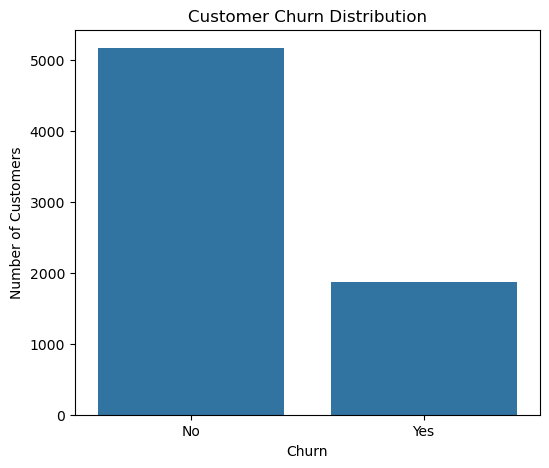

In [33]:
plt.figure(figsize=(6,5))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [35]:
# it shows the customers who left and who stays
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

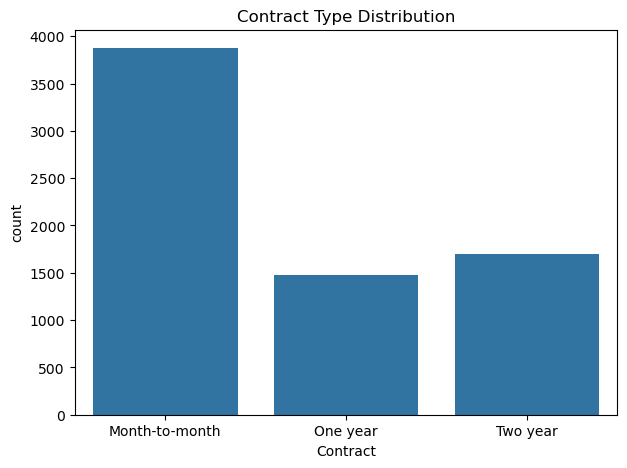

In [36]:
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', data=df)
plt.title("Contract Type Distribution")
plt.show()

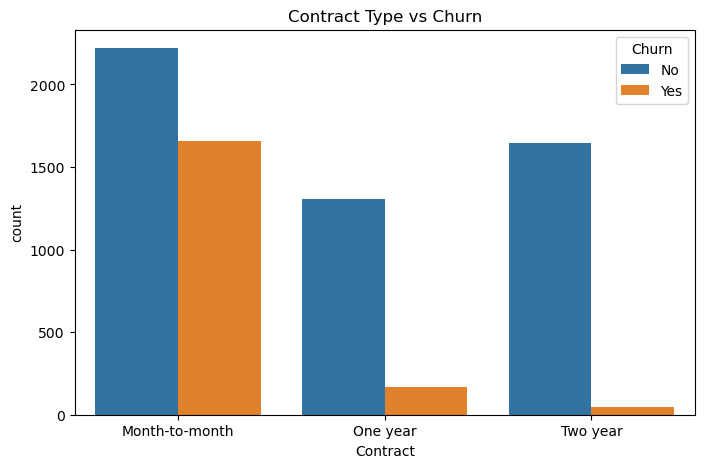

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

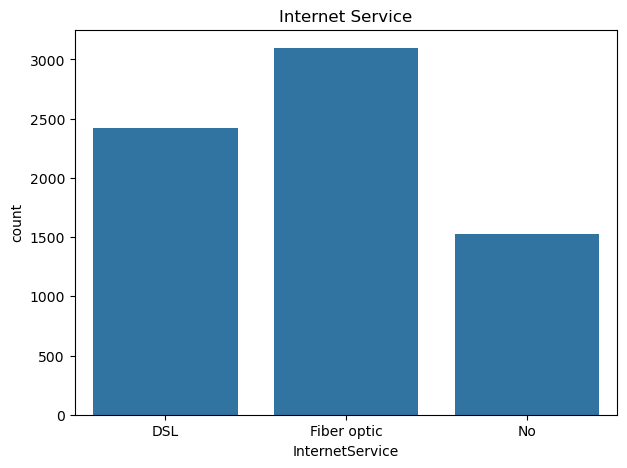

In [38]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', data=df)
plt.title("Internet Service")
plt.show()

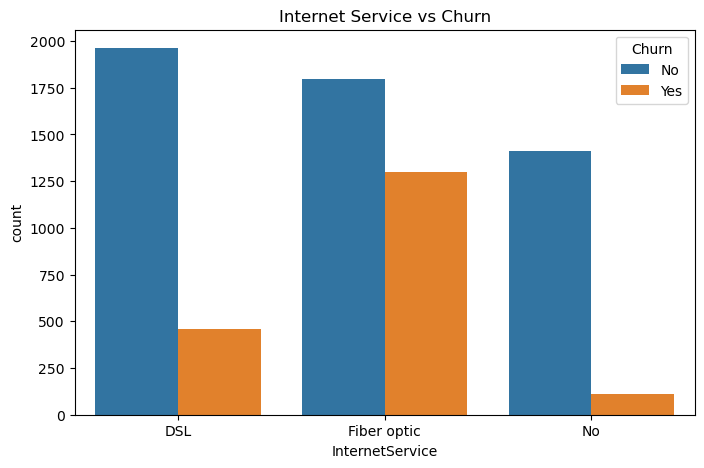

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

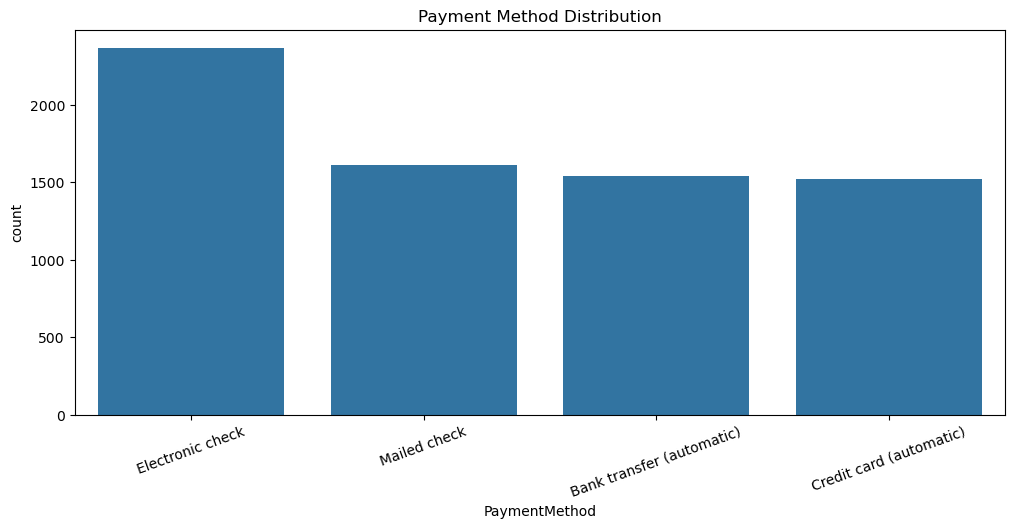

In [40]:
plt.figure(figsize=(12,5))
sns.countplot(x='PaymentMethod', data=df)
plt.xticks(rotation=20)
plt.title("Payment Method Distribution")
plt.show()

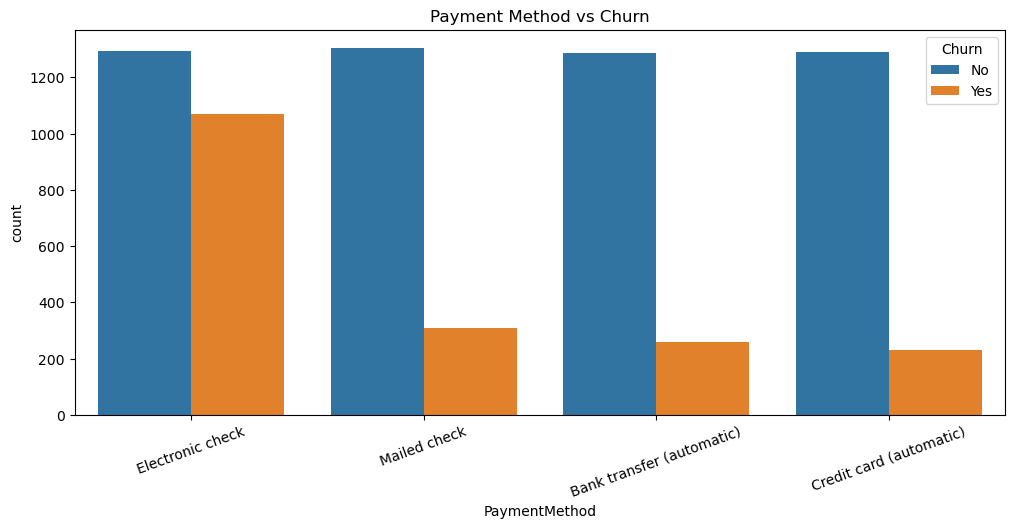

In [42]:
plt.figure(figsize=(12,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")
plt.show()

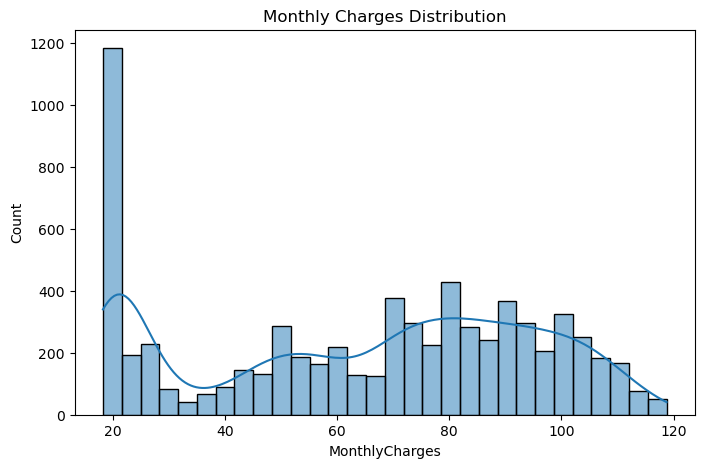

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

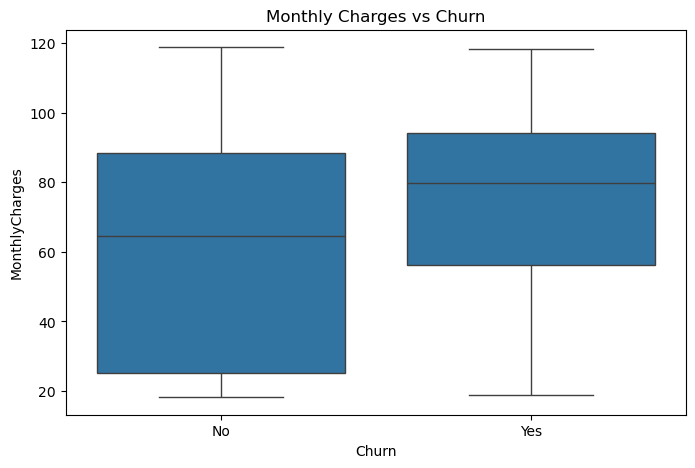

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

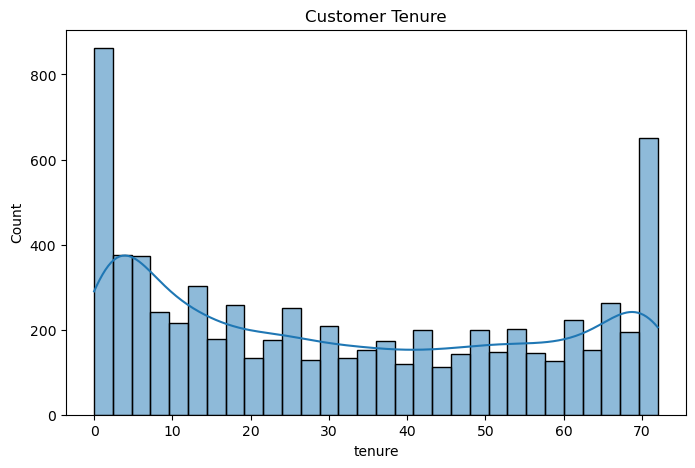

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Customer Tenure")
plt.show()

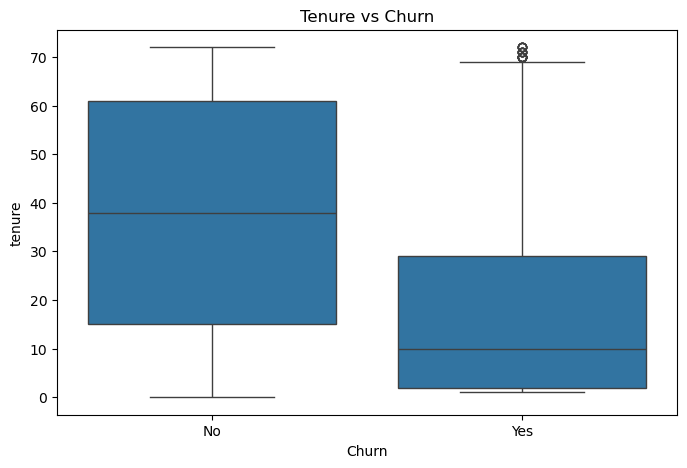

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

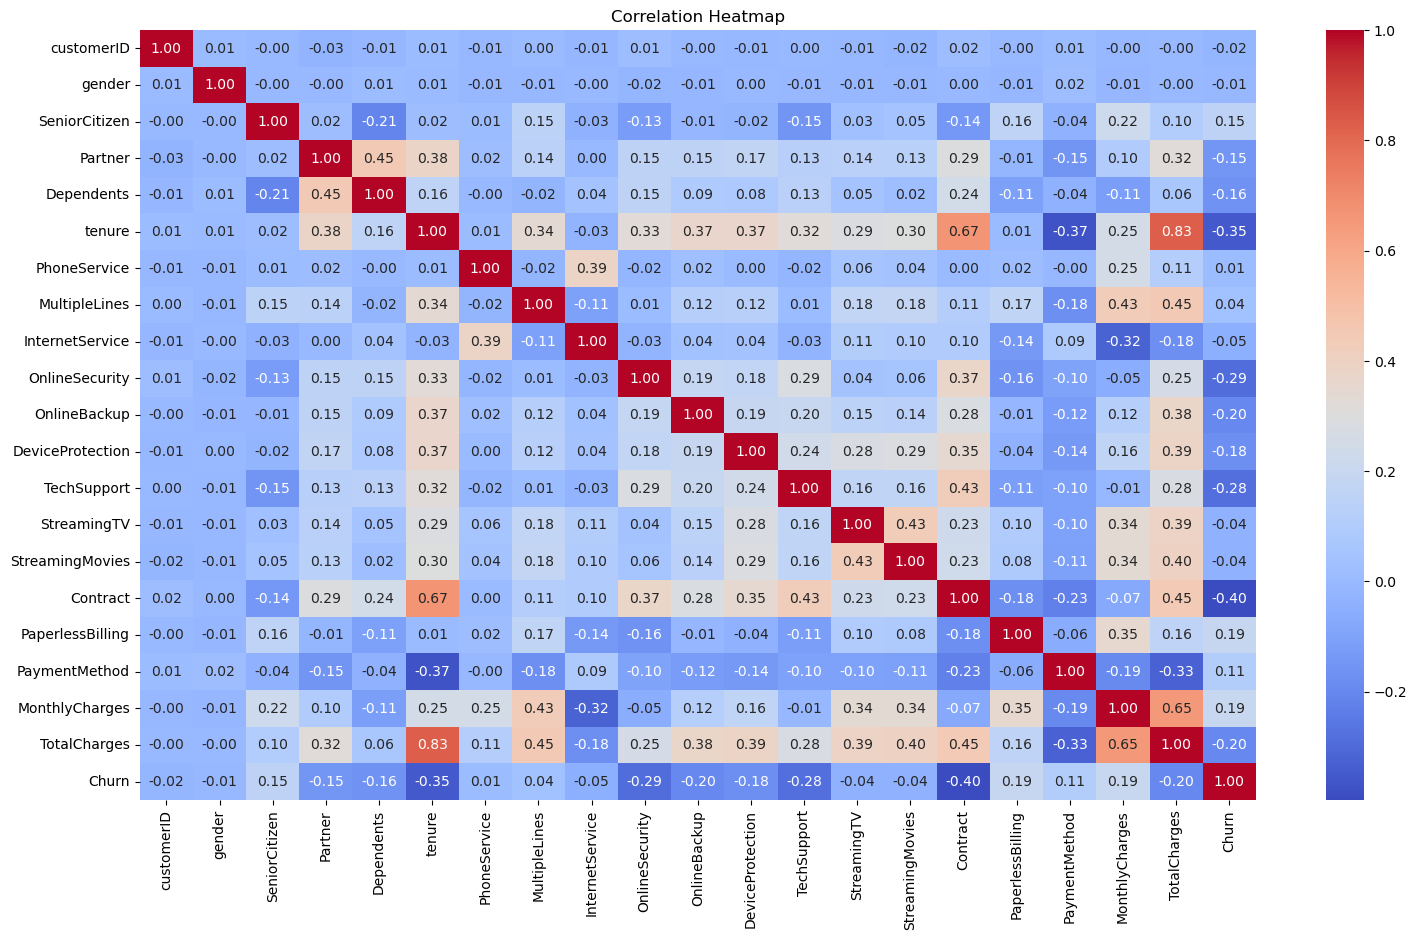

In [47]:
# a copy of the dataset
df_corr = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = le.fit_transform(df_corr[col])
plt.figure(figsize=(18,10))
sns.heatmap(df_corr.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [51]:
# now we have preprocees that data
df.head()

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [52]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [53]:
# now we have to drop the customer id..it uniquly identifies it does not use to churn
df.drop("customerID", axis=1, inplace=True)

In [54]:
# now we are converting the strings into numbers because it ml doesnot understands 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [55]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [56]:
# Features
X = df.drop("Churn", axis=1)
# Target
y = df["Churn"]

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
# now we are splitting data into training and testing for analysis
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

In [59]:
print(y_train.value_counts())
print(y_test.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64
Churn
0    1036
1     373
Name: count, dtype: int64


In [60]:
# Import Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Import Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [61]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [62]:
# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.815471965933286


In [63]:
print(confusion_matrix(y_test, lr_pred))

[[933 103]
 [157 216]]


In [64]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [70]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Model Trained Successfully!")
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy :", dt_accuracy)
print("Decision confusion matrix:")
print(confusion_matrix(y_test, dt_pred))
print("Decision tree classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Model Trained Successfully!
Decision Tree Accuracy : 0.7246273953158269
Decision confusion matrix:
[[832 204]
 [184 189]]
Decision tree classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.49       373

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.73      1409



In [73]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Model Trained Successfully!")
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy :", rf_accuracy)
print("Random Forest confusion matrix:")
print(confusion_matrix(y_test, rf_pred))
print("Random Forest classification report:")
print(classification_report(y_test, rf_pred))

Random Forest Model Trained Successfully!
Random Forest Accuracy : 0.7970191625266146
Random Forest confusion matrix:
[[945  91]
 [195 178]]
Random Forest classification report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



In [74]:
accuracy = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})
accuracy

,Model,Accuracy
0,Logistic Regression,0.815472
1,Decision Tree,0.724627
2,Random Forest,0.797019


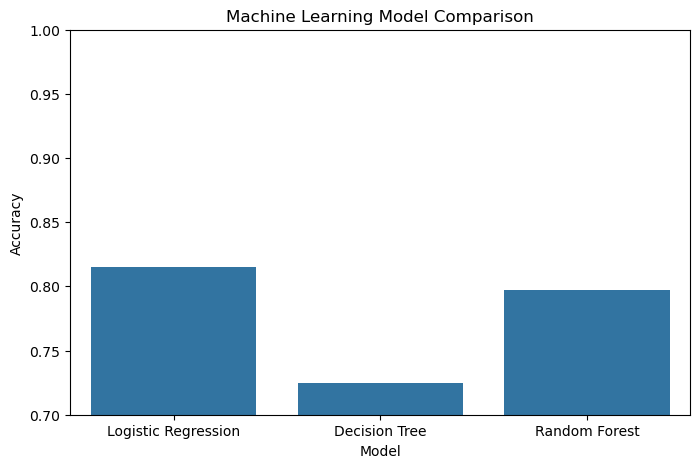

In [75]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=accuracy
)
plt.title("Machine Learning Model Comparison")
plt.ylim(0.70,1.00)
plt.show()

In [76]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [77]:
print("---------- Logistic Regression ----------")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("\n---------- Decision Tree ----------")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision :", precision_score(y_test, dt_pred))
print("Recall :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("\n---------- Random Forest ----------")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

---------- Logistic Regression ----------
Accuracy : 0.815471965933286
Precision : 0.677115987460815
Recall : 0.579088471849866
F1 Score : 0.6242774566473989

---------- Decision Tree ----------
Accuracy : 0.7246273953158269
Precision : 0.48091603053435117
Recall : 0.5067024128686327
F1 Score : 0.4934725848563969

---------- Random Forest ----------
Accuracy : 0.7970191625266146
Precision : 0.6617100371747212
Recall : 0.4772117962466488
F1 Score : 0.5545171339563862


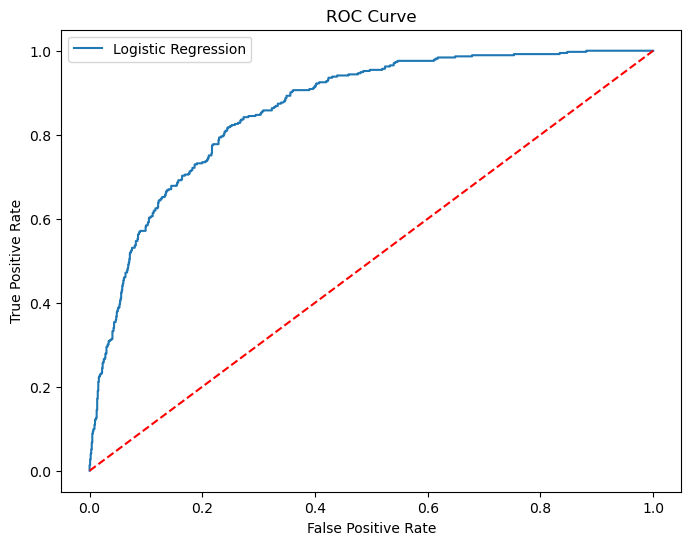

In [78]:
lr_prob = lr.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, lr_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [79]:
roc = roc_auc_score(y_test, lr_prob)
print("ROC AUC Score :", roc)

ROC AUC Score : 0.8613389816472926


In [80]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
18,TotalCharges,0.189992
17,MonthlyCharges,0.177867
4,tenure,0.157428
14,Contract,0.077357
16,PaymentMethod,0.050379
8,OnlineSecurity,0.047432
11,TechSupport,0.044190
0,gender,0.028117
9,OnlineBackup,0.027067
7,InternetService,0.026444


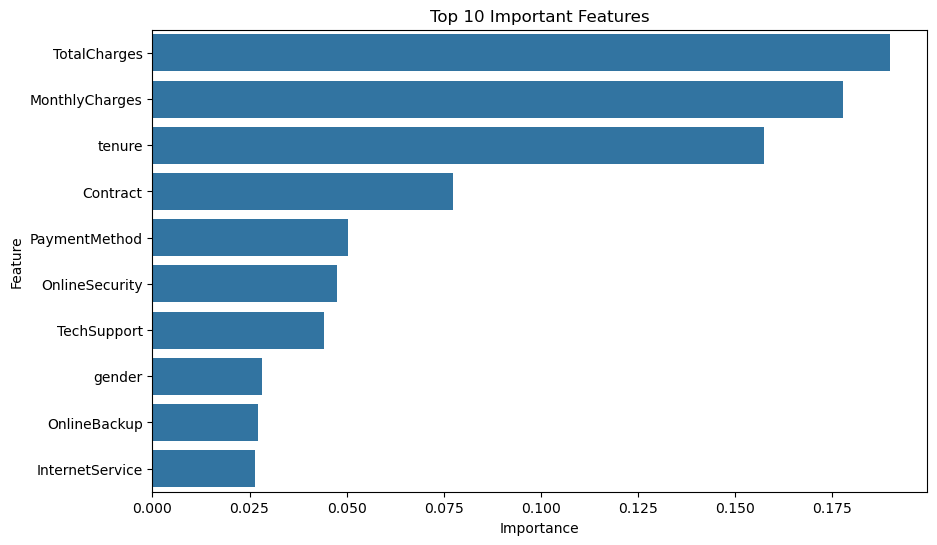

In [81]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()

In [82]:
new_customer = X.iloc[[0]]
prediction = rf.predict(new_customer)
if prediction[0]==1:
    print("Customer is likely to Churn")
else:
    print("Customer is likely to Stay")

Customer is likely to Stay


In [83]:
import joblib
joblib.dump(rf,"Customer_Churn_Model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [84]:
loaded_model = joblib.load("Customer_Churn_Model.pkl")
loaded_model.predict(new_customer)

array([0])

In [85]:
print("""BUSINESS INSIGHTS
1. Month-to-month contract customers have higher churn.
2. Customers with short tenure leave more frequently.
3. Higher monthly charges increase churn probability.
4. Long-term contracts improve retention.
5. Customers using automatic payment methods
   generally show lower churn.
6. Retention campaigns should focus on
   high-risk customers.""")

BUSINESS INSIGHTS
1. Month-to-month contract customers have higher churn.
2. Customers with short tenure leave more frequently.
3. Higher monthly charges increase churn probability.
4. Long-term contracts improve retention.
5. Customers using automatic payment methods
   generally show lower churn.
6. Retention campaigns should focus on
   high-risk customers.


In [ ]:
________________________________________THANK YOU_________________________________